In [1]:
import os
from pathlib import Path
REPO = Path.cwd().resolve().parents[1]          # docs/notebooks -> repo root
GOLDEN = Path(os.environ.get("CAL_DISP_GOLDEN_DIR", REPO / "test_golden"))
SCRATCH = Path(os.environ.get("TMPDIR", REPO / "tmp")) / "cal_disp_notebooks"; SCRATCH.mkdir(parents=True, exist_ok=True)

import json
import subprocess
import sys

import h5py
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 90
print("repo:", REPO)
print("golden:", GOLDEN, GOLDEN.exists())

repo: /u/aurora-r0/govorcin/01_OPERA/VLM/DISP_CAL/gamma_release/cal-disp
golden: /u/aurora-r0/govorcin/01_OPERA/VLM/DISP_CAL/gamma_release/cal-disp/test_golden True


# 03 — Load the displacement once, as float32

**Defect.** `run_calibration` read the `displacement` layer through xarray's `.values`
(`src/cal_disp/workflow.py:520` at commit `5d66555`, the state before the fix):

```python
disp_2d = ds_disp.displacement.values.astype(np.float32)
```

The layer is **float64 on disk** (7733 x 9464 pixels = 585 MB for the golden frame). `.values` loads the whole
float64 array and, with xarray's default `cache=True`, keeps it in the dataset for the rest of the run; the
fit only ever uses the float32 copy. So the run carried 585 MB (float64 cache) + 293 MB (float32) where
293 MB is enough. (Earlier, at `dcce716`, the layer was read a second time at line 480 for the nodata count;
that read was served from the same cache, so the memory picture was the same. The nodata count has since
moved to the calibration surface and is not touched here.)

**Fix.** `cal_disp.workflow._load_displacement` reads row blocks into a preallocated float32 array: the
full float64 array is never held and nothing is cached in the dataset. A NaN stays a NaN in float32, so the
valid mask derived from the array is unchanged.

**This notebook** measures the load step on the golden DISP product, old way vs new way, each in a fresh
subprocess (so the peak RSS of one does not leak into the other), and checks that the array and its NaN
count are unchanged. Reported per variant:

* `baseline`: peak RSS after the imports, before anything is loaded;
* `peak`: peak RSS (`resource.getrusage(...).ru_maxrss`) at the end of the load step;
* `held`: current RSS (`/proc/self/status` VmRSS) after the load step, with the dataset still open as it is
  in the workflow - what the run keeps carrying afterwards.

In [2]:
disp_file = next((GOLDEN / "input_data" / "disp").glob("OPERA_L3_DISP-S1_*.nc"))
with h5py.File(disp_file) as f:
    d = f["displacement"]
    print(f"{disp_file.name}\n  /displacement: dtype {d.dtype}, shape {d.shape}, chunks {d.chunks},"
          f" {d.size * d.dtype.itemsize / 1e6:.0f} MB in memory as {d.dtype}, {d.size * 4 / 1e6:.0f} MB as float32")

WORKER = r"""
import hashlib, json, resource, sys, time
import numpy as np
from cal_disp.product import DispProduct
from cal_disp.workflow import _load_displacement

mode, path = sys.argv[1], sys.argv[2]

def peak_gb():
    return resource.getrusage(resource.RUSAGE_SELF).ru_maxrss * 1024 / 1e9      # ru_maxrss is in kB on Linux

def held_gb():
    with open("/proc/self/status") as f:
        return next(int(line.split()[1]) for line in f if line.startswith("VmRSS:")) * 1024 / 1e9

baseline = peak_gb()
t0 = time.time()
ds_disp = DispProduct.from_path(path).open_dataset()            # as in run_calibration
if mode == "old":                                               # the previous code
    disp_2d = ds_disp.displacement.values.astype(np.float32)
else:                                                           # the fixed code
    disp_2d = _load_displacement(ds_disp)
seconds = time.time() - t0
peak, held = peak_gb(), held_gb()                               # measured before anything else is allocated
print(json.dumps({
    "mode": mode, "baseline_gb": baseline, "peak_gb": peak, "held_gb": held, "seconds": seconds,
    "nan_count": int(np.count_nonzero(np.isnan(disp_2d))), "dtype": str(disp_2d.dtype), "shape": list(disp_2d.shape),
    "cached_in_dataset": bool(ds_disp["displacement"].variable._in_memory),
    "sha256": hashlib.sha256(disp_2d.tobytes()).hexdigest(),
}))
"""
worker = SCRATCH / "nb03_load_worker.py"
worker.write_text(WORKER)

def measure(mode: str) -> dict:
    out = subprocess.run([sys.executable, str(worker), mode, str(disp_file)], check=True, capture_output=True, text=True)
    return json.loads(out.stdout.strip().splitlines()[-1])

runs = {mode: [measure(mode) for _ in range(3)] for mode in ("old", "new")}      # 3 repeats each
for mode, reps in runs.items():
    for r in reps:
        print(f"{mode}: baseline {r['baseline_gb']:.2f} GB, peak {r['peak_gb']:.2f} GB, held {r['held_gb']:.2f} GB,"
              f" {r['seconds']:.1f} s, NaN pixels {r['nan_count']:,}, float64 cached in dataset: {r['cached_in_dataset']}")

OPERA_L3_DISP-S1_IW_F08882_VV_20220111T002651Z_20220722T002657Z_v1.0_20251027T005420Z.nc
  /displacement: dtype float64, shape (7733, 9464), chunks (256, 256), 585 MB in memory as float64, 293 MB as float32


old: baseline 0.26 GB, peak 1.16 GB, held 1.16 GB, 3.1 s, NaN pixels 25,750,140, float64 cached in dataset: True
old: baseline 0.27 GB, peak 1.17 GB, held 1.17 GB, 2.6 s, NaN pixels 25,750,140, float64 cached in dataset: True
old: baseline 0.27 GB, peak 1.17 GB, held 1.17 GB, 3.0 s, NaN pixels 25,750,140, float64 cached in dataset: True
new: baseline 0.27 GB, peak 0.62 GB, held 0.58 GB, 3.3 s, NaN pixels 25,750,140, float64 cached in dataset: False
new: baseline 0.26 GB, peak 0.61 GB, held 0.57 GB, 3.3 s, NaN pixels 25,750,140, float64 cached in dataset: False
new: baseline 0.26 GB, peak 0.61 GB, held 0.57 GB, 2.9 s, NaN pixels 25,750,140, float64 cached in dataset: False


                                   old (.values)    new (_load_displacement)
peak RSS (GB)                               1.16                        0.61
RSS held after load (GB)                    1.16                        0.57
baseline RSS (GB)                           0.26                        0.26
load time (s)                               3.08                        3.27
peak above baseline (GB)                    0.90                        0.34
NaN pixels in the array               25,750,140                  25,750,140
dtype                                    float32                     float32

NaN count unchanged (25,750,140); float32 arrays bit-identical (sha256 47a7e9c448bd609b...)
peak RSS of the load step: 1.16 GB -> 0.61 GB (0.56 GB less); held afterwards: 1.16 GB -> 0.57 GB


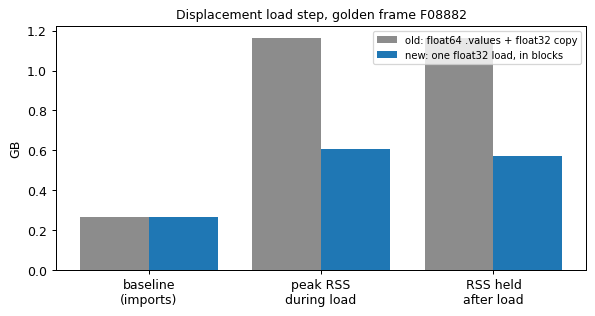

In [3]:
old, new = (min(runs[m], key=lambda r: r["peak_gb"]) for m in ("old", "new"))
print(f"{'':28s}{'old (.values)':>20s}{'new (_load_displacement)':>28s}")
for key, label in [("peak_gb", "peak RSS (GB)"), ("held_gb", "RSS held after load (GB)"),
                   ("baseline_gb", "baseline RSS (GB)"), ("seconds", "load time (s)")]:
    print(f"{label:28s}{old[key]:20.2f}{new[key]:28.2f}")
print(f"{'peak above baseline (GB)':28s}{old['peak_gb'] - old['baseline_gb']:20.2f}{new['peak_gb'] - new['baseline_gb']:28.2f}")
print(f"{'NaN pixels in the array':28s}{old['nan_count']:20,d}{new['nan_count']:28,d}")
print(f"{'dtype':28s}{old['dtype']:>20s}{new['dtype']:>28s}")

assert old["nan_count"] == new["nan_count"], "NaN count changed"
assert old["sha256"] == new["sha256"] and old["dtype"] == new["dtype"] == "float32", "array changed"
print(f"\nNaN count unchanged ({new['nan_count']:,}); float32 arrays bit-identical (sha256 {new['sha256'][:16]}...)")
print(f"peak RSS of the load step: {old['peak_gb']:.2f} GB -> {new['peak_gb']:.2f} GB"
      f" ({old['peak_gb'] - new['peak_gb']:.2f} GB less); held afterwards: {old['held_gb']:.2f} GB -> {new['held_gb']:.2f} GB")

fig, ax = plt.subplots(figsize=(6.5, 3.4), constrained_layout=True)
labels = ["baseline\n(imports)", "peak RSS\nduring load", "RSS held\nafter load"]
keys = ["baseline_gb", "peak_gb", "held_gb"]
x = range(len(keys))
ax.bar([i - 0.2 for i in x], [old[k] for k in keys], width=0.4, label="old: float64 .values + float32 copy", color="0.55")
ax.bar([i + 0.2 for i in x], [new[k] for k in keys], width=0.4, label="new: one float32 load, in blocks", color="tab:blue")
ax.set_xticks(list(x)); ax.set_xticklabels(labels); ax.set_ylabel("GB"); ax.legend(fontsize=8)
ax.set_title("Displacement load step, golden frame F08882", fontsize=10)
plt.show()